In [267]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np

In [268]:
X,y = make_regression(n_samples = 100,n_features=1,n_informative=1,n_targets=1,noise=20,random_state=13)

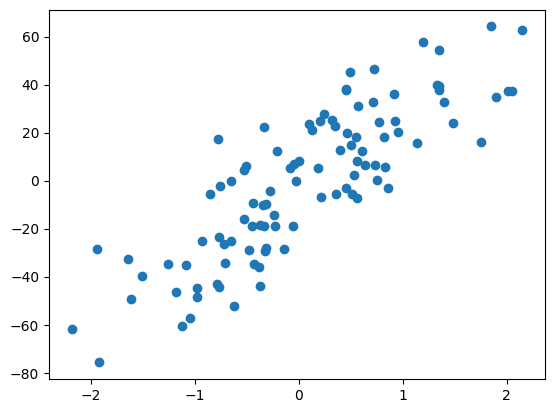

In [269]:
plt.scatter(X,y)

In [270]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X,y)
print(lr.coef_)
print(lr.intercept_)

[27.82809103]
-2.29474455867698


In [271]:
from sklearn.linear_model import Ridge
r = Ridge(alpha=10)
r.fit(X,y)
print(r.coef_)
print(r.intercept_)

[24.9546267]
-2.1269130035235735


In [272]:
from sklearn.linear_model import Ridge
r1 = Ridge(alpha=100)
r1.fit(X,y)
print(r1.coef_)
print(r1.intercept_)

[12.93442104]
-1.4248441496033308


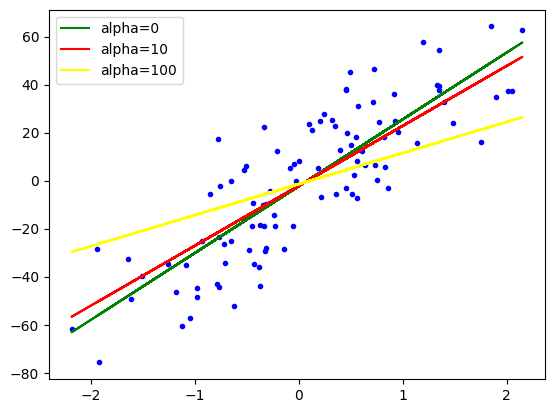

In [273]:
plt.plot(X,y,'b.')
plt.plot(X,lr.predict(X),color="green",label="alpha=0")
plt.plot(X,r.predict(X),color="red",label="alpha=10")
plt.plot(X,r1.predict(X),color="yellow",label="alpha=100")
plt.legend()

In [274]:
## 2d dim code
class Ridge:
  def __init__(self,alpha=0.1):
    self.alpha=alpha
    self.m=None,
    self.b = None
  def fit(self,X_train,y_train):

    num = 0
    den = 0

    for i in range(X_train.shape[0]):
      num = num + (y_train[i] - y_train.mean())* (X_train[i]- X_train.mean())
      den = den + (X_train[i] -X_train.mean())* (X_train[i] -X_train.mean())

    self.m = num/(den + self.alpha)
    self.b = y_train.mean() - (self.m * X_train.mean())
    print(self.m,self.b)

  def predict(X_test):
    pass

In [275]:
ri = Ridge(100)

In [276]:
ri.fit(X,y)

[12.93442104] [-1.42484415]


## N dim

In [277]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [278]:
data = load_diabetes()

In [279]:
X = data.data
y=data.target

In [280]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=4)

In [281]:
r = Ridge(alpha=0.1,solver="cholesky")

In [282]:
r.fit(X_train,y_train)

Ridge(alpha=0.1, solver='cholesky')

In [283]:
y_pred = r.predict(X_test)

In [284]:
print(r2_score(y_test,y_pred))

0.4693128853309805


In [285]:
print(r.coef_)
print(r.intercept_)

[  44.02063391 -241.69329987  452.98665299  332.04420177  -76.33686744
  -68.52143809 -164.98809083  149.96908118  431.61347417   58.51862681]
150.89053425602808


###### The reason of using [0][0]=0 is that because in our matrix W the first term is basically intercept not slope and we have to multiply Lambda with only slopes.Thats why first term became zero and lambda is multiplied with only slopes.

In [286]:
class MeraRidge:

    def __init__(self,alpha=0.1):

        self.alpha = alpha
        self.coef_ = None
        self.intercept_ = None

    def fit(self,X_train,y_train):

        X_train = np.insert(X_train,0,1,axis=1)
        I = np.identity(X_train.shape[1])
        I[0][0] = 0
        result = np.linalg.inv(np.dot(X_train.T,X_train) + self.alpha * I).dot(X_train.T).dot(y_train)
        self.intercept_ = result[0]
        self.coef_ = result[1:]

    def predict(self,X_test):
        return np.dot(X_test,self.coef_) + self.intercept_
reg = MeraRidge()
reg.fit(X_train,y_train)
y_pred = reg.predict(X_test)
print(r2_score(y_test,y_pred))
print(reg.coef_)
print(reg.intercept_)

0.4693128853309805
[  44.02063391 -241.69329987  452.98665299  332.04420177  -76.33686744
  -68.52143809 -164.98809083  149.96908118  431.61347417   58.51862681]
150.8905342560281
